# Visualisation 3D

In [23]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.mplot3d import Axes3D

In [24]:
# ce mode d'interaction va nous permettre de nous déplacer
# dans l'espace pour voir les courbes en 3D
# depuis plusieurs points de vue

# Pour bénéficier du mode d’interaction plus riche avec une figure
# ça nécessite l’installation de ipympl
# %matplotlib ipympl

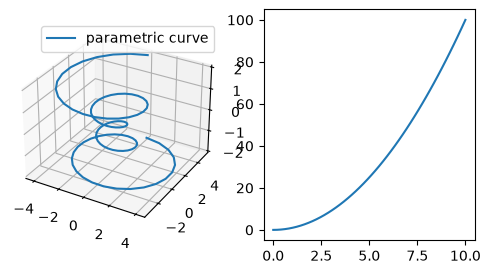

In [25]:
fig = plt.figure(figsize=(6, 3))

ax = fig.add_subplot(121, projection='3d')

theta = np.linspace(-4 *np.pi, 4 * np.pi, 100)
z = np.linspace(-2, 2, 100)
r = z**2 + 1
x = r * np.sin(theta)
y = r * np.cos(theta)

ax.plot(x, y, z, label='parametric curve')
ax.legend()

ax2 = fig.add_subplot(122)
x = np.linspace(0, 10)
y = x**2

ax2.plot(x, y)
plt.show()

## `Axes3DSubplot.scatter`

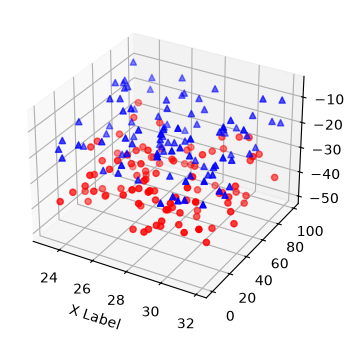

In [26]:
fig = plt.figure(figsize=(4, 4))

def randrange(n, vmin, vmax):
    return (vmax - vmin)*np.random.rand(n) + vmin

ax = fig.add_subplot(111, projection='3d')

n = 100

for c, m, zlow, zhigh in [('r', 'o', -50, -25), ('b', '^', -30, -5)]:
    xs = randrange(n, 23, 32)
    ys = randrange(n, 0, 100)
    zs = randrange(n, zlow, zhigh)
    ax.scatter(xs, ys, zs, c=c, marker=m)

ax.set_xlabel('X Label')
plt.show()

## `Axes3DSubplot.plot_wireframe`

Utilisez cette méthode pour dessiner en mode "fil de fer".

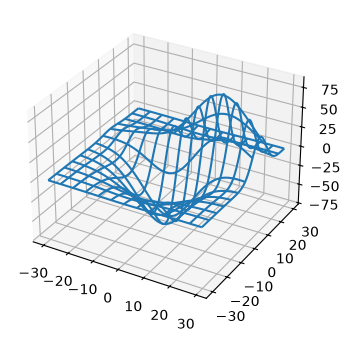

In [28]:
from mpl_toolkits.mplot3d import axes3d

fig = plt.figure(figsize=(4, 4))

ax = fig.add_subplot(111, projection='3d')

# Grab some test data.
X, Y, Z = axes3d.get_test_data(0.05)

# Plot a basic wireframe.
ax.plot_wireframe(X, Y, Z, rstride=10, cstride=10)
plt.show()

## `Axes3DSubplot.plot_surface`

In [29]:
from matplotlib import cm
from matplotlib.ticker import LinearLocator,  FormatStrFormatter

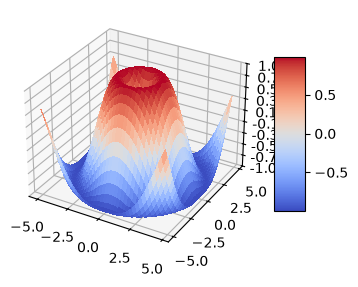

In [30]:
fig = plt.figure(figsize=(4, 4))

ax = fig.add_subplot(111, projection='3d')

X = np.arange(-5, 5, 0.25)
Y = np.arange(-5, 5, 0.25)
X, Y = np.meshgrid(X, Y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R)

# Plot the surface.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.set_zlim(-1.01, 1.01)
ax.zaxis.set_major_locator(LinearLocator(10))
ax.zaxis.set_major_formatter(FormatStrFormatter('%.02f'))

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=5)

plt.show()

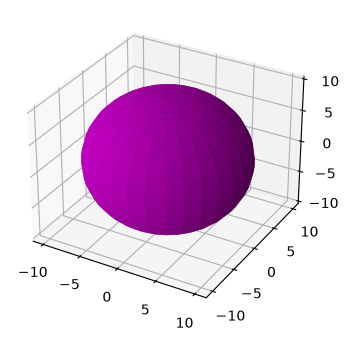

In [33]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')

u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x = 10 * np.outer(np.cos(u), np.sin(v))
y = 10 * np.outer(np.sin(u), np.sin(v))
z = 10 * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x, y, z, color='m')

plt.show()

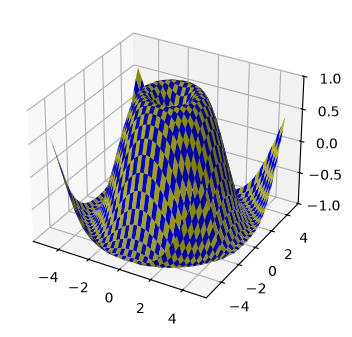

In [34]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')

X = np.arange(-5, 5, 0.25)
xlen = len(X)
Y = np.arange(-5, 5, 0.25)
ylen = len(Y)
X, Y = np.meshgrid(X, Y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R)

colortuple = ('y', 'b')
colors = np.empty(X.shape, dtype=str)
for y in range(ylen):
    for x in range(xlen):
        colors[x, y] = colortuple[(x + y) % len(colortuple)]


surf = ax.plot_surface(X, Y, Z, facecolors=colors, linewidth=0)

ax.set_zlim(-1, 1)

plt.show()

## `Axes3DSubplot.plot_trisurf`


`plot_trisurf` se prête aussi au rendu de surfaces, mais sur la base de maillages en triangles.

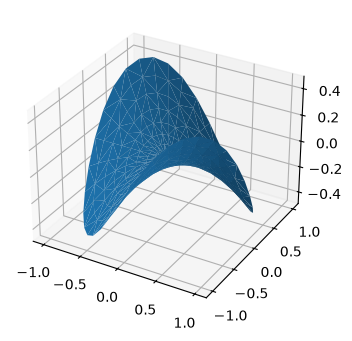

In [35]:
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')

n_radii = 8
n_angles = 36

radii = np.linspace(0.125, 1.0, n_radii)
angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)

angles = np.repeat(angles[..., np.newaxis], n_radii, axis=1)

x = np.append(0, (radii*np.cos(angles)).flatten())
y = np.append(0, (radii*np.sin(angles)).flatten())

z = np.sin(-x*y)

ax.plot_trisurf(x, y, z, linewidth=0.2, antialiased=True)

plt.show()

In [36]:
import matplotlib.tri as mtri

In [ ]:
fig = plt.figure(figsize=(6, 3))

u = np.linspace(0, 2.0 * np.pi, endpoint=True, num=50)
v = np.linspace(-0.5, 0.5, endpoint=True, num=10)
u, v = np.meshgrid(u, v)
u, v = u.flatten(), v.flatten()

# Ceci est le paramétrage de Möbius : 
# il prend une paire (u, v) et renvoie un triplet (x, y, z).
x = (1 + 0.5 * v * np.cos(u / 2.0)) * np.cos(u)
y = (1 + 0.5 * v * np.cos(u / 2.0)) * np.sin(u)
z = 0.5 * v * np.sin(u / 2.0)

# Trianguler l'espace des paramètres pour déterminer les triangles.
tri = mtri.Triangulation(u, v)

# Tracer la surface. 
# Les triangles dans l'espace des paramètres déterminent 
# les points x, y, z reliés par une arête.
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot_trisurf(x, y, z, triangles=tri.triangles, cmap=plt.cm.Spectral)
ax.set_zlim(-1, 1)


#============
# Deuxième graphique
#============

# Définir les espaces de paramètres des rayons et des angles.
n_angles = 36
n_radii = 8
min_radius = 0.25
radii = np.linspace(min_radius, 0.95, n_radii)

angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)
angles = np.repeat(angles[..., np.newaxis], n_radii, axis=1)
angles[:, 1::2] += np.pi/n_angles

# Convertir les paires rayon-angle en points x, y, z.
x = (radii*np.cos(angles)).flatten()
y = (radii*np.sin(angles)).flatten()
z = (np.cos(radii)*np.cos(angles*3.0)).flatten()

# Créer la triangulation ; 
# sans triangles fournis, une triangulation de Delaunay est créée.
triang = mtri.Triangulation(x, y)

# Masquer les triangles indésirables.
xmid = x[triang.triangles].mean(axis=1)
ymid = y[triang.triangles].mean(axis=1)
mask = np.where(xmid**2 + ymid**2 < min_radius**2, 1, 0)
triang.set_mask(mask)

# Tracer la surface.
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.plot_trisurf(triang, z, cmap=plt.cm.CMRmap)

plt.show()